#**Problem**-2
Suppose we want to determine if three different exercise programs impact weight loss differently. We recruit 90 people to participate in an experiment in which we randomly assign (using uniform distribution) 30 people to follow either Program A, Program B, or Program C for one month. The predictor variable being studied is the exercise program, and the response variable is weight loss, measured in pounds.

Conduct a one-way ANOVA to determine if there is a statistically significant difference between the resulting weight loss from the three programs, check the model assumptions, and analyze treatment differences.

In [30]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [31]:
#Create dataset
np.random.seed(42)

A = np.random.normal(loc=5, scale=1.5, size=30)
B = np.random.normal(loc=8, scale=1.5, size=30)
C = np.random.normal(loc=4, scale=1.5, size=30)

In [32]:
#Combine into DataFrame
df = pd.DataFrame({
    'WeightLoss': np.concatenate([A, B, C]),
    'Program': ['A']*30 + ['B']*30 + ['C']*30
})

df.head(35)

,WeightLoss,Program
0,5.745071,A
1,4.792604,A
2,5.971533,A
3,7.284545,A
4,4.648770,A
5,4.648795,A
6,7.368819,A
7,6.151152,A
8,4.295788,A
9,5.813840,A


In [33]:
###Basic EDA##
#Group Means
df.groupby('Program')['WeightLoss'].mean()

,WeightLoss
Program,
A,4.717780
B,7.818256
C,4.019327


In [34]:
#Group Standard Deviations
df.groupby('Program')['WeightLoss'].std()

,WeightLoss
Program,
A,1.350010
B,1.396653
C,1.487975


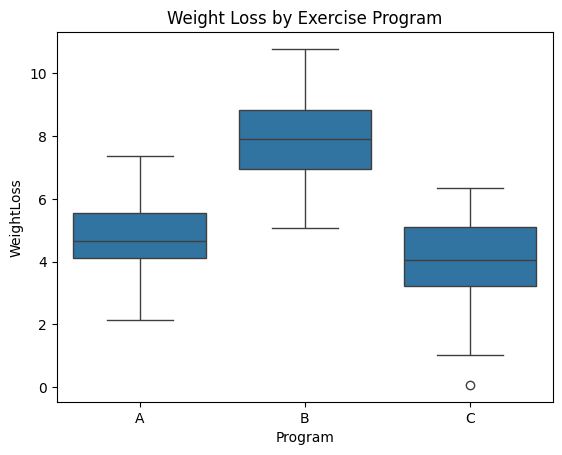

In [35]:
#Boxplot
sns.boxplot(x='Program', y='WeightLoss', data=df)

plt.title("Weight Loss by Exercise Program")

plt.show()

The boxplot shows that weight loss differs across the three exercise programs.

Program B has the highest median weight loss, indicating it is the most effective program overall.
Program A shows moderate weight loss with less variability.
Program C has the lowest median weight loss and includes a possible outlier near 0.

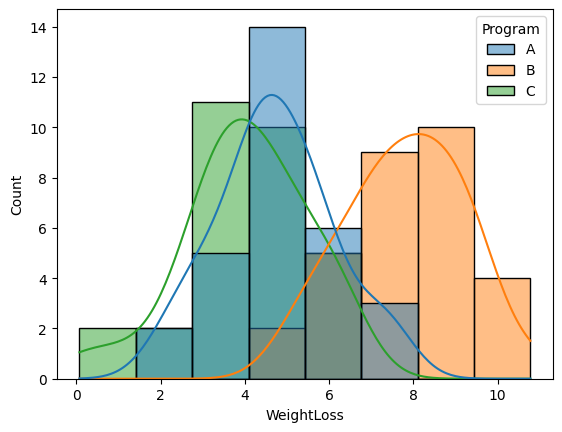

In [36]:
#Distribution Plot
sns.histplot(data=df, x='WeightLoss', hue='Program', kde=True)

plt.show()

##ONE way ANOVA test
ANOVA Assumptions

Before ANOVA we check:


1.   Independence
2.   Normality
3.   Equal Variance



In [37]:
#Nomality check(Shapiro-wilk test)
for group in df['Program'].unique():

    stat, p = stats.shapiro(
        df[df['Program']==group]['WeightLoss']
    )

    print(group)
    print("P-value:", p)
    print()

A
P-value: 0.686805494291708

B
P-value: 0.9129582559088034

C
P-value: 0.36537361581254685



SInce p > 0.05 so it is normal

In [38]:
#Homogeneity of Variance

#Levene’s Test

stat, p = stats.levene(A, B, C)

print("P-value:", p)

P-value: 0.8626638812717601


Since p > 0.05 so equal variances

In [40]:
del C

In [41]:
model = ols(
    'WeightLoss ~ C(Program)',
    data=df
).fit()

In [42]:
#ANOVA Table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                sum_sq    df          F        PR(>F)
C(Program)  245.326539   2.0  61.462398  2.287256e-17
Residual    173.629808  87.0        NaN           NaN


The one-way ANOVA results show that there is a statistically significant difference in mean weight loss among the three exercise programs.

The F-statistic is 61.46, which is quite large.
The p-value is 2.29 × 10⁻¹⁷, which is much smaller than 0.05.

Since:

p<0.05

p<0.05

we reject the null hypothesis that all program means are equal.

This indicates that at least one exercise program produces a significantly different average weight loss compared to the others.

In [43]:
#Post Hoc Test (Tukey HSD)
tukey = pairwise_tukeyhsd(
    endog=df['WeightLoss'],
    groups=df['Program'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   3.1005    0.0  2.2307  3.9702   True
     A      C  -0.6985 0.1406 -1.5682  0.1713  False
     B      C  -3.7989    0.0 -4.6687 -2.9292   True
----------------------------------------------------


**Interpretation of Tukey HSD Test**

The Tukey HSD post hoc test was conducted to identify which exercise programs differ significantly in mean weight loss.

Results show:

Program B differs significantly from Program A (p < 0.05).
Program B also differs significantly from Program C (p < 0.05).
There is no significant difference between Program A and Program C (p = 0.1406).

Program B produced the highest average weight loss, indicating that it is significantly more effective than both Programs A and C.

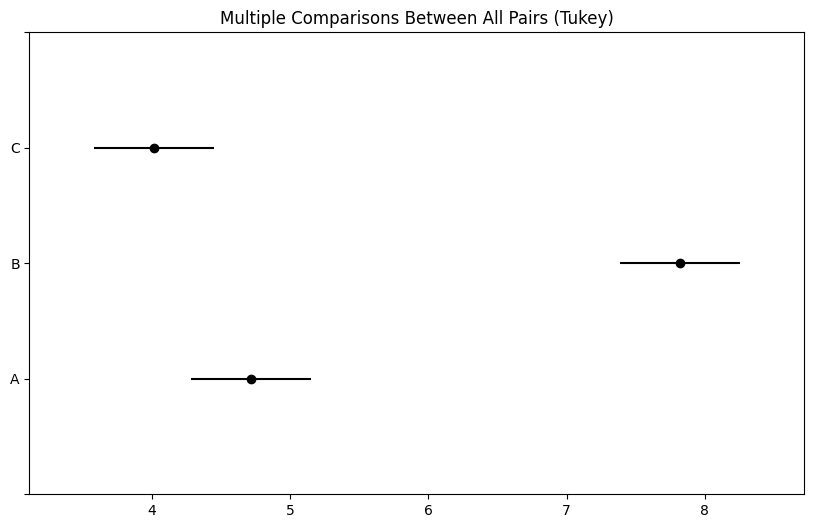

In [44]:
tukey.plot_simultaneous()

plt.show()

In [46]:
residuals = model.resid

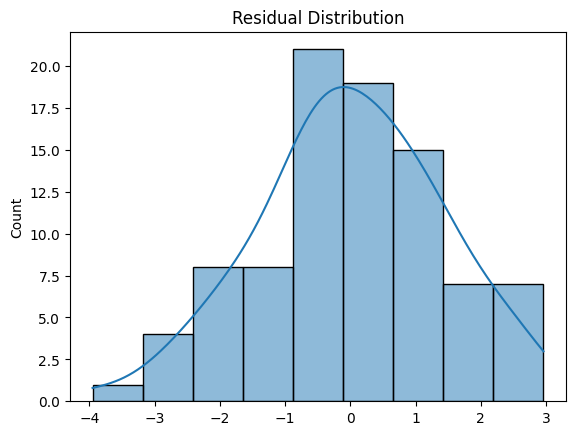

In [47]:
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

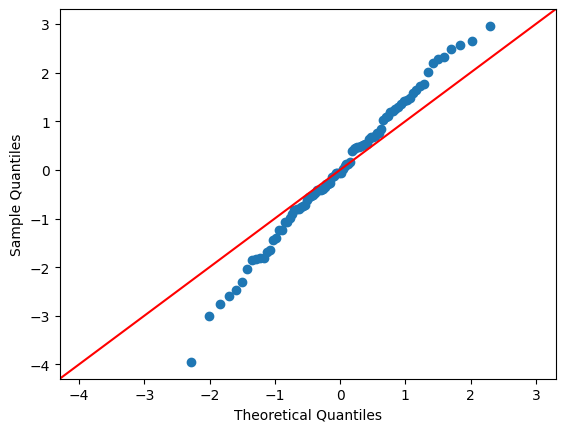

In [48]:
sm.qqplot(residuals, line='45')

plt.show()

The residual is quite normally distributed